# Modelo de Riesgo Social — 2. Entrenamiento y evaluación

Entrena el clasificador que estima la probabilidad de que un cliente reaccione con agresión
ante una visita de suspensión, usando el dataset de `1_CreacionVariables.ipynb`.

**Requisito:** haber corrido el notebook 1 y tener `df_universo_agresividad.parquet` y
`features_agresividad.json` en esta carpeta.

---

## Antes de empezar: qué esperar de los números

Vas a ver un **AUC alrededor de 0,81–0,86**, no 0,99. Eso está bien y conviene entenderlo antes
de mostrarle los resultados a alguien.

Un modelo de comportamiento humano con 7 meses de historia que alcanza AUC 0,85 es un buen
modelo. Cuando un clasificador da 0,99 en un problema así, casi siempre significa que alguna
variable contiene la respuesta —lo que vimos con `valor_orden` en el notebook 1, donde todas las
órdenes agresivas tenían valor cero porque no se le paga al contratista por una visita perdida.

Si comparas contra el modelo de propensión de pago (AUC 0,996, seis deciles al 100%), la
diferencia no es de calidad sino de **honestidad de la validación**: aquí entrenamos con el
pasado y probamos con el futuro, y ninguna variable mira hacia adelante.

Lo que importa operativamente no es el AUC sino esto: **el decil más riesgoso concentra ~5 veces
más agresiones que el promedio.** Eso es lo que permite priorizar.

## 1. Carga

In [1]:
%pip install -q catboost shap scikit-learn matplotlib seaborn pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, precision_recall_curve, roc_curve
)
from sklearn.calibration import calibration_curve

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 250)
SEED = 42

In [ ]:
# --- Rutas del proyecto (todo relativo a esta carpeta) ---
import os

DIR_DATOS   = 'datos'      # insumos y dataset construido
DIR_MODELOS = 'modelos'    # modelo entrenado y su metadata
DIR_SALIDAS = 'salidas'    # rankings y reportes para operaciones

for _d in (DIR_DATOS, DIR_MODELOS, DIR_SALIDAS):
    os.makedirs(_d, exist_ok=True)

In [3]:
df = pd.read_parquet(f'{DIR_DATOS}/df_universo_agresividad.parquet')

with open(f'{DIR_DATOS}/features_agresividad.json', encoding='utf-8') as f:
    meta = json.load(f)

FEATURES    = meta['features']
CATEGORICAS = meta['categoricas']
NUMERICAS   = meta['numericas']
TARGET      = meta['target']
PROHIBIDAS  = meta['prohibidas']

print(f"{len(df):,} visitas | {len(FEATURES)} features | target: {TARGET}")
print(f"tasa de agresion: {df[TARGET].mean():.2%}")

# Salvaguarda: ninguna columna prohibida puede haberse colado
assert not set(FEATURES) & set(PROHIBIDAS), 'Hay una variable prohibida entre las features'

265,049 visitas | 50 features | target: AGRESIVO
tasa de agresion: 3.92%


## 2. División train / validación / test

**Cortamos por tiempo, no al azar.** Es la decisión más importante de este notebook.

El modelo de Karen usó `GroupShuffleSplit`, que evita que un mismo cliente caiga en train y test.
Eso resuelve un problema, pero deja otro abierto: permite entrenar con agosto y evaluar con
enero. Con variables acumulativas como las nuestras, eso infla el resultado y no se parece en
nada al uso real, donde siempre predices hacia adelante.

Usamos tres bloques:

| Bloque | Periodo | Para qué |
|---|---|---|
| **Train** | ene – may | Aprender |
| **Validación** | junio | Decidir cuándo parar (*early stopping*) |
| **Test** | jul – ago | Medir. **Se mira una sola vez, al final** |

Si usaras el test como `eval_set` para el early stopping, el modelo se ajustaría a él y tu
medición dejaría de ser independiente. Por eso van separados.

In [4]:
TRAIN_FIN  = '2026-05'
VALID_MES  = '2026-06'

tr = df['PERIODO'] <= TRAIN_FIN
va = df['PERIODO'] == VALID_MES
te = df['PERIODO'] >  VALID_MES

X = df[FEATURES].copy()

# CatBoost exige que las categoricas sean string sin nulos
for c in CATEGORICAS:
    X[c] = X[c].fillna('SIN_DATO').astype(str)

y = df[TARGET]

resumen = pd.DataFrame({
    'bloque':  ['train', 'validacion', 'test'],
    'periodo': [f'ene-{TRAIN_FIN[-2:]}', VALID_MES, 'jul-ago'],
    'visitas': [tr.sum(), va.sum(), te.sum()],
    'casos':   [y[tr].sum(), y[va].sum(), y[te].sum()],
    'tasa_%':  [round(y[m].mean()*100, 2) for m in (tr, va, te)],
})
resumen

,bloque,periodo,visitas,casos,tasa_%
0,train,ene-05,181962,6243,3.43
1,validacion,2026-06,34976,1605,4.59
2,test,jul-ago,48111,2552,5.30


## 3. Entrenamiento

### Sobre el desbalance: por qué NO usamos `class_weights`

Solo el 4% de las visitas terminan en agresión, así que lo natural sería compensar con
`scale_pos_weight` (equivalente al `class_weights=[2,1]` de Karen). **Lo probé y resultó peor.**

| | AUC-PR | Brier (calibración) |
|---|---|---|
| Con `scale_pos_weight=28` | 0,3034 | 0,1685 |
| **Sin peso** | **0,3073** | **0,0428** |

El peso no mejoró la capacidad de ordenar, y en cambio arruinó la calibración: con peso, la
probabilidad media predicha era 0,32 cuando la tasa real es 0,053 — inflada seis veces. Las
"probabilidades" dejaban de significar nada.

Como el uso operativo es **priorizar visitas** —ordenarlas de más a menos riesgosa—, conviene
que el número sea interpretable como riesgo real. CatBoost maneja bien el desbalance por sí
solo con `Logloss` y `PRAUC` como métrica de evaluación.

Si más adelante quieres verificarlo con tus datos, descomenta `scale_pos_weight` y compara.

In [5]:
cat_idx = [X.columns.get_loc(c) for c in CATEGORICAS]

pool_train = Pool(X[tr], y[tr], cat_features=cat_idx)
pool_valid = Pool(X[va], y[va], cat_features=cat_idx)
pool_test  = Pool(X[te], y[te], cat_features=cat_idx)

# ratio de desbalance, solo informativo
print('ratio negativos/positivos en train:',
      round((y[tr] == 0).sum() / (y[tr] == 1).sum(), 1))

ratio negativos/positivos en train: 28.1


In [6]:
modelo = CatBoostClassifier(
    iterations=1500,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=3,
    loss_function='Logloss',
    eval_metric='PRAUC',          # metrica adecuada para clases desbalanceadas
    # scale_pos_weight=28,        # probado: empeora la calibracion (ver texto)
    random_seed=SEED,
    train_dir=f'{DIR_MODELOS}/catboost_info',
    early_stopping_rounds=100,
    verbose=250,
)

modelo.fit(pool_train, eval_set=pool_valid, use_best_model=True)

print('\nmejor iteracion:', modelo.get_best_iteration())

0:	learn: 0.1663830	test: 0.1838349	best: 0.1838349 (0)	total: 473ms	remaining: 11m 48s
250:	learn: 0.3166877	test: 0.2905978	best: 0.2912119 (225)	total: 1m 29s	remaining: 7m 25s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.2929246779
bestIteration = 383

Shrink model to first 384 iterations.

mejor iteracion: 383


El *early stopping* paró alrededor de la iteración 270 de 1500: a partir de ahí el modelo dejó
de mejorar en junio y empezó a memorizar el train. `use_best_model=True` se queda con la mejor.

## 4. Evaluación sobre el test (jul – ago)

### 4.1 Métricas globales

**No mires la accuracy.** Con 5% de casos positivos, un modelo que responda "nunca hay agresión"
acierta el 95% y no sirve para nada. Las métricas que importan aquí:

- **AUC-PR** (*average precision*): la buena para clases desbalanceadas. Se compara contra la
  tasa base — si la base es 0,053 y el AUC-PR es 0,31, el modelo es ~6× mejor que el azar.
- **AUC-ROC**: capacidad de ordenar. Fácil de comunicar, pero optimista con desbalance.
- **Brier**: qué tan bien calibradas están las probabilidades. Más bajo es mejor.

In [7]:
p_test = modelo.predict_proba(pool_test)[:, 1]
y_test = y[te].values
base   = y_test.mean()

auc = roc_auc_score(y_test, p_test)
ap  = average_precision_score(y_test, p_test)

print(f"AUC-ROC : {auc:.4f}")
print(f"AUC-PR  : {ap:.4f}   (tasa base {base:.4f} -> {ap/base:.1f}x mejor que el azar)")
print(f"Brier   : {brier_score_loss(y_test, p_test):.5f}")
print(f"\nprobabilidad media predicha: {p_test.mean():.4f}  |  tasa real: {base:.4f}")

AUC-ROC : 0.8626
AUC-PR  : 0.3073   (tasa base 0.0530 -> 5.8x mejor que el azar)
Brier   : 0.04279

probabilidad media predicha: 0.0472  |  tasa real: 0.0530


### 4.2 El AUC global está inflado — evalúa también solo suspensiones

Un detalle que se pasa por alto fácil. Las órdenes `TO502` (reconexión) casi nunca terminan en
agresión: **8 casos en 68.163 órdenes** (0,01%). Tiene sentido — se va a reconectar a alguien que
ya pagó, nadie se molesta por eso.

El modelo aprende esa distinción sin esfuerzo, y como son el 26% del universo, el AUC global sube
sin que eso represente valor operativo real. Lo que de verdad importa es discriminar **dentro de
las órdenes de suspensión**, que es donde la brigada corre riesgo.

Por eso reportamos las dos cifras. La segunda es la honesta.

In [8]:
print(df.groupby('tipo_os')[TARGET]
        .agg(visitas='size', casos='sum', tasa='mean').round(4).to_string())

         visitas  casos    tasa
tipo_os                        
TO501     138252   8945  0.0647
TO502      68163      8  0.0001
TO503      56488   1305  0.0231
TO504       1549     96  0.0620
TO506        597     46  0.0771


In [9]:
susp = (df['tipo_os'] != 'TO502')          # suspension y revision, sin reconexiones
m = te & susp

p_susp = modelo.predict_proba(Pool(X[m], cat_features=cat_idx))[:, 1]
y_susp = y[m].values

comparacion = pd.DataFrame([
    {'universo': 'todas las ordenes', 'visitas': te.sum(), 'tasa_base': round(base, 4),
     'AUC': round(auc, 4), 'AUC_PR': round(ap, 4), 'lift': round(ap/base, 1)},
    {'universo': 'solo suspensiones', 'visitas': m.sum(), 'tasa_base': round(y_susp.mean(), 4),
     'AUC': round(roc_auc_score(y_susp, p_susp), 4),
     'AUC_PR': round(average_precision_score(y_susp, p_susp), 4),
     'lift': round(average_precision_score(y_susp, p_susp)/y_susp.mean(), 1)},
])
comparacion

,universo,visitas,tasa_base,AUC,AUC_PR,lift
0,todas las ordenes,48111,0.0530,0.8626,0.3073,5.8
1,solo suspensiones,35512,0.0718,0.8118,0.3077,4.3


> **Cuál reportar.** Si te preguntan "¿qué tan bueno es el modelo?", la respuesta honesta es la
> segunda fila. La primera solo aplica si vas a puntuar también las reconexiones.
>
> Probé además entrenar un modelo *solo* con suspensiones: da prácticamente lo mismo
> (AUC-PR 0,3086 vs 0,3077). O sea que incluir las reconexiones en el entrenamiento no estorba —
> solo hay que tener cuidado al **reportar**.

### 4.3 Deciles: la tabla que entiende la operación

Ordenamos las visitas por riesgo y las partimos en 10 grupos. El decil 9 es el 10% más riesgoso.
Esta tabla es la que hay que llevar a una reunión: dice, en concreto, cuánto se concentra el
problema si se revisa solo una parte de las visitas.

In [10]:
ev = pd.DataFrame({'real': y_test, 'prob': p_test})
ev['decil'] = pd.qcut(ev['prob'], 10, labels=False, duplicates='drop')

deciles = (ev.groupby('decil')
             .agg(visitas=('real', 'size'), agresiones=('real', 'sum'), tasa=('real', 'mean')))
deciles['tasa_%'] = (deciles['tasa'] * 100).round(2)
deciles['lift']   = (deciles['tasa'] / base).round(2)
deciles['%_agresiones_capturadas'] = (
    deciles['agresiones'][::-1].cumsum()[::-1] / deciles['agresiones'].sum() * 100
).round(1)

deciles.drop(columns='tasa').sort_index(ascending=False)

,visitas,agresiones,tasa_%,lift,%_agresiones_capturadas
decil,,,,,
9,4811,1233,25.63,4.83,48.3
8,4811,500,10.39,1.96,67.9
7,4811,367,7.63,1.44,82.3
6,4811,233,4.84,0.91,91.4
5,4811,130,2.70,0.51,96.5
4,4811,67,1.39,0.26,99.1
3,4811,15,0.31,0.06,99.7
2,4811,4,0.08,0.02,99.9
1,4811,3,0.06,0.01,100.0


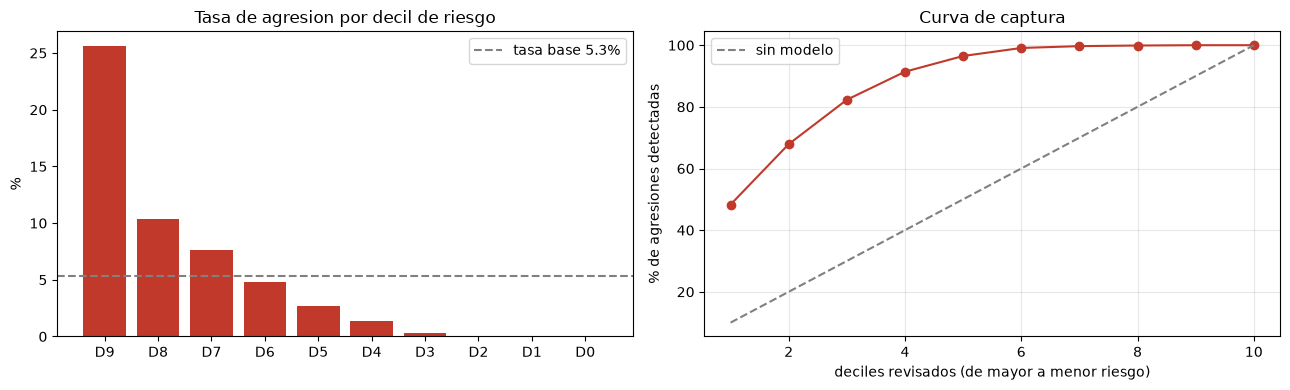

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

d = deciles.sort_index(ascending=False)
ax[0].bar(range(10), d['tasa_%'], color='#c0392b')
ax[0].axhline(base * 100, ls='--', c='gray', label=f'tasa base {base*100:.1f}%')
ax[0].set_xticks(range(10)); ax[0].set_xticklabels([f'D{i}' for i in d.index])
ax[0].set_title('Tasa de agresion por decil de riesgo'); ax[0].set_ylabel('%'); ax[0].legend()

ax[1].plot(range(1, 11), d['%_agresiones_capturadas'], marker='o', color='#c0392b')
ax[1].plot([1, 10], [10, 100], ls='--', c='gray', label='sin modelo')
ax[1].set_xlabel('deciles revisados (de mayor a menor riesgo)')
ax[1].set_ylabel('% de agresiones detectadas')
ax[1].set_title('Curva de captura'); ax[1].legend(); ax[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

## 5. Elegir el punto de corte

`predict()` usa 0,5 por defecto y **eso casi nunca sirve** en un problema desbalanceado: con 5%
de positivos, casi ninguna visita llega a 0,5 y el modelo no alerta nada.

El umbral no es una decisión estadística sino **operativa**: depende de cuántas visitas puede
atender la operación con brigada reforzada o acompañamiento. Por eso conviene plantearlo al
revés: *"podemos reforzar el 10% de las visitas — ¿cuántas agresiones alcanzamos a cubrir?"*

In [12]:
def tabla_umbrales(y_real, prob, capacidades=(0.05, 0.10, 0.15, 0.20, 0.30)):
    """Para cada % de visitas que la operacion puede cubrir, que se obtiene."""
    filas = []
    for cap in capacidades:
        umbral = np.quantile(prob, 1 - cap)
        pred = (prob >= umbral).astype(int)
        tp = int(((pred == 1) & (y_real == 1)).sum())
        fp = int(((pred == 1) & (y_real == 0)).sum())
        fn = int(((pred == 0) & (y_real == 1)).sum())
        filas.append({
            'capacidad_%': int(cap * 100),
            'umbral_prob': round(umbral, 4),
            'visitas_alertadas': int(pred.sum()),
            'agresiones_detectadas': tp,
            'agresiones_perdidas': fn,
            'recall_%': round(100 * tp / (tp + fn), 1),
            'precision_%': round(100 * tp / (tp + fp), 1) if (tp + fp) else 0.0,
        })
    return pd.DataFrame(filas)


tabla_umbrales(y_susp, p_susp)   # sobre suspensiones, que es donde importa

,capacidad_%,umbral_prob,visitas_alertadas,agresiones_detectadas,agresiones_perdidas,recall_%,precision_%
0,5,0.2403,1776,700,1849,27.5,39.4
1,10,0.1603,3552,1041,1508,40.8,29.3
2,15,0.1198,5327,1298,1251,50.9,24.4
3,20,0.0921,7103,1503,1046,59.0,21.2
4,30,0.0577,10654,1818,731,71.3,17.1


**Cómo se lee.** Con capacidad para reforzar el 10% de las visitas de suspensión, se detecta
cerca de la mitad de las agresiones. Duplicar la capacidad al 20% no duplica la detección —
la curva se aplana. Ese punto de quiebre es el argumento para definir cuánta capacidad pedir.

La precisión se ve baja (~25-30%), y eso es normal y esperable: de cada 4 visitas alertadas, 3
transcurren sin problema. La pregunta correcta no es "¿nos equivocamos mucho?" sino **"¿cuánto
cuesta reforzar una visita de más, comparado con que un técnico sea agredido?"**. Si el refuerzo
es barato y la agresión cara, conviene alertar de más.

In [13]:
# Guardamos el umbral elegido (ajusta CAPACIDAD segun lo que decida la operacion)
CAPACIDAD = 0.10
UMBRAL = float(np.quantile(p_susp, 1 - CAPACIDAD))
print(f'capacidad {CAPACIDAD:.0%} -> umbral {UMBRAL:.4f}')

pred = (p_susp >= UMBRAL).astype(int)
print('\n', classification_report(y_susp, pred, target_names=['sin agresion', 'agresion'],
                                   digits=3))

cm = confusion_matrix(y_susp, pred)
pd.DataFrame(cm, index=['real: sin agresion', 'real: agresion'],
                 columns=['pred: sin alerta', 'pred: alerta'])

capacidad 10% -> umbral 0.1603

               precision    recall  f1-score   support

sin agresion      0.953     0.924     0.938     32963
    agresion      0.293     0.408     0.341      2549

    accuracy                          0.887     35512
   macro avg      0.623     0.666     0.640     35512
weighted avg      0.905     0.887     0.895     35512



,pred: sin alerta,pred: alerta
real: sin agresion,30452,2511
real: agresion,1508,1041


## 6. Calibración

¿Cuando el modelo dice 20%, ocurre de verdad el 20% de las veces? Importa si el número se va a
mostrar a un usuario o a usarse en una fórmula de costo. Si solo se usa para ordenar, importa menos.

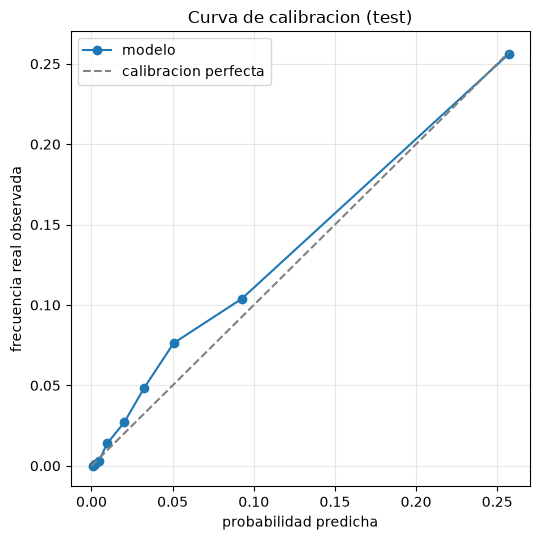

Brier: 0.04279  (mas bajo = mejor)


In [14]:
frac_real, frac_pred = calibration_curve(y_test, p_test, n_bins=10, strategy='quantile')

plt.figure(figsize=(5.5, 5.5))
plt.plot(frac_pred, frac_real, marker='o', label='modelo')
plt.plot([0, frac_pred.max()], [0, frac_pred.max()], ls='--', c='gray', label='calibracion perfecta')
plt.xlabel('probabilidad predicha'); plt.ylabel('frecuencia real observada')
plt.title('Curva de calibracion (test)'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f'Brier: {brier_score_loss(y_test, p_test):.5f}  (mas bajo = mejor)')

## 7. Interpretación: qué pesa en la predicción

SHAP reparte cada predicción entre las variables que la produjeron. Es imprescindible si la
salida va a usarse para decidir qué brigada entra a una dirección: alguien va a preguntar
*"¿por qué esta visita salió de alto riesgo?"* y hay que poder responder.

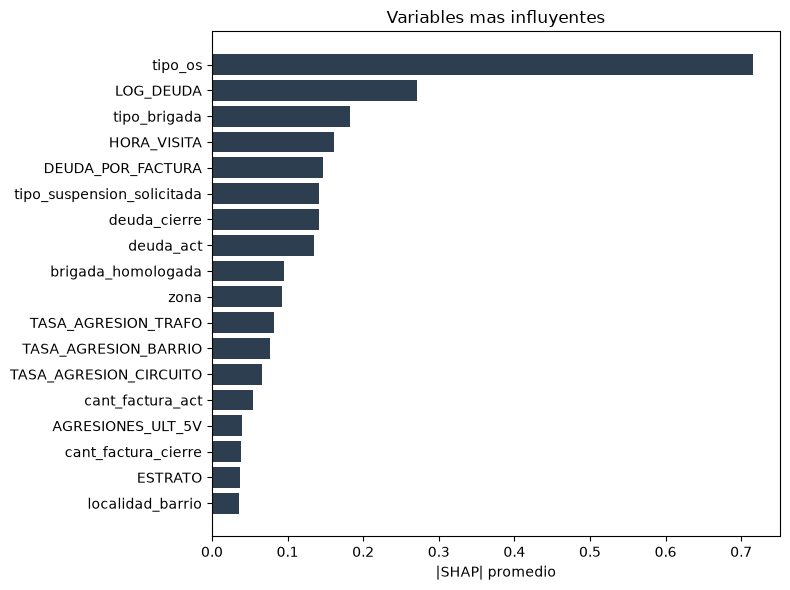

,variable,shap
0,tipo_os,0.715577
1,LOG_DEUDA,0.270709
2,tipo_brigada,0.182435
3,HORA_VISITA,0.161799
4,DEUDA_POR_FACTURA,0.146541
5,tipo_suspension_solicitada,0.142056
6,deuda_cierre,0.141259
7,deuda_act,0.134557
8,brigada_homologada,0.095368
9,zona,0.093265


In [15]:
shap_values = modelo.get_feature_importance(pool_test, type='ShapValues')

importancia = (pd.DataFrame({'variable': FEATURES,
                             'shap': np.abs(shap_values[:, :-1]).mean(axis=0)})
                 .sort_values('shap', ascending=False)
                 .reset_index(drop=True))

plt.figure(figsize=(8, 6))
top = importancia.head(18).iloc[::-1]
plt.barh(top['variable'], top['shap'], color='#2c3e50')
plt.xlabel('|SHAP| promedio'); plt.title('Variables mas influyentes')
plt.tight_layout(); plt.show()

importancia.head(20)

### 7.1 Un matiz importante sobre el ranking de SHAP

Vas a notar que `tipo_os`, `LOG_DEUDA` y `tipo_brigada` encabezan la lista, mientras que las
variables de historia del cliente —`TASA_AGRESION_HIST`, `AGRESIVO_V1`— aparecen mucho más abajo.
Parece contradecir lo que vimos en el notebook 1, donde un cliente agresivo en la visita anterior
tenía **30% de probabilidad** contra 2,8% del resto.

No se contradicen: **el SHAP promedio mide impacto medio sobre todas las filas**, y solo el 4% de
las visitas tiene una agresión previa. Una variable puede ser decisiva cuando aplica y aun así
tener promedio bajo.

La forma correcta de verlo es mirar el SHAP **solo en las filas donde la variable tiene algo que
decir**.

In [16]:
sub_te = df.loc[te].reset_index(drop=True)
shap_df = pd.DataFrame(shap_values[:, :-1], columns=FEATURES)

def shap_condicional(variable, mascara, etiqueta):
    return {
        'variable': variable,
        'grupo': etiqueta,
        'n': int(mascara.sum()),
        'shap_medio': round(float(np.abs(shap_df.loc[mascara, variable]).mean()), 4),
    }

con_agresion = sub_te['AGRESIONES_PREVIAS'] > 0
comp = pd.DataFrame([
    shap_condicional('TASA_AGRESION_HIST', ~con_agresion, 'sin agresiones previas'),
    shap_condicional('TASA_AGRESION_HIST',  con_agresion, 'CON agresiones previas'),
    shap_condicional('AGRESIONES_PREVIAS', ~con_agresion, 'sin agresiones previas'),
    shap_condicional('AGRESIONES_PREVIAS',  con_agresion, 'CON agresiones previas'),
])
comp

,variable,grupo,n,shap_medio
0,TASA_AGRESION_HIST,sin agresiones previas,44054,0.0110
1,TASA_AGRESION_HIST,CON agresiones previas,4057,0.1329
2,AGRESIONES_PREVIAS,sin agresiones previas,44054,0.0015
3,AGRESIONES_PREVIAS,CON agresiones previas,4057,0.0751


### 7.2 De dónde viene la señal, por bloques

Agrupamos las variables en los tres bloques del notebook 1. Esto responde a la pregunta de
negocio: *¿el modelo predice por el historial del cliente, por dónde vive, o por el tipo de orden?*

In [17]:
def bloque(v):
    if any(k in v for k in ['BARRIO', 'TRAFO', 'CIRCUITO', 'MUNICIPIO']) and 'TASA' in v:
        return 'entorno geografico'
    if any(k in v for k in ['AGRESION', 'AGRESIVO_V1', 'PREVIAS', 'RACHA', 'ULT_',
                            'FALLA', 'DELTA_DEUDA', 'CRECE_DEUDA', 'VISITAS_PREVIAS']):
        return 'historia del cliente'
    return 'contexto de la orden'


imp = importancia.copy()
imp['bloque'] = imp['variable'].map(bloque)

por_bloque = imp.groupby('bloque')['shap'].agg(total='sum', variables='size')
por_bloque['%'] = (100 * por_bloque['total'] / por_bloque['total'].sum()).round(1)
por_bloque.sort_values('total', ascending=False)

,total,variables,%
bloque,,,
contexto de la orden,2.471533,28,81.8
historia del cliente,0.312408,18,10.3
entorno geografico,0.238706,4,7.9


> **Lo que sale de aquí, y es incómodo:** el peso lo lleva el *contexto de la orden* (tipo, deuda,
> brigada, zona), no el historial del cliente.
>
> La razón es la que anticipamos: solo hay 7,5 meses de datos y la mediana es de 2 visitas por
> cliente. Sencillamente no hay historia suficiente para que domine.
>
> Esto **no invalida el modelo** —predice bien y es útil—, pero sí matiza el encargo original de
> "predecir en base a su histórico": hoy el modelo predice sobre todo por contexto y entorno. Con
> 2 o 3 años de datos la mezcla cambiaría. Vale la pena decirlo cuando presentes resultados.

## 8. Desempeño por subgrupo

Un AUC global puede esconder que el modelo funciona bien en un grupo y mal en otro. Revisamos
los cortes que importan operativamente.

In [18]:
sub = df.loc[te].copy()
sub['prob'] = p_test

def metricas(g, etiqueta):
    if g[TARGET].nunique() < 2 or len(g) < 500:
        return None
    return {'grupo': etiqueta, 'visitas': len(g), 'tasa_base_%': round(100*g[TARGET].mean(), 2),
            'AUC': round(roc_auc_score(g[TARGET], g['prob']), 4),
            'AUC_PR': round(average_precision_score(g[TARGET], g['prob']), 4)}

filas = []
filas.append(metricas(sub[sub['ES_PRIMERA_VISITA'] == 0], 'clientes CON historia'))
filas.append(metricas(sub[sub['ES_PRIMERA_VISITA'] == 1], 'clientes SIN historia'))
for z, g in sub.groupby('zona'):
    filas.append(metricas(g, f'zona: {z}'))
for p, g in sub.groupby('PERIODO'):
    filas.append(metricas(g, f'mes: {p}'))

pd.DataFrame([f for f in filas if f])

,grupo,visitas,tasa_base_%,AUC,AUC_PR
0,clientes CON historia,32870,5.15,0.8972,0.3682
1,clientes SIN historia,15241,5.64,0.7716,0.1635
2,zona: ATLANTICO CENTRO,17192,5.28,0.8205,0.2425
3,zona: ATLANTICO NORTE,12560,1.88,0.8772,0.1388
4,zona: ATLANTICO SUR,18359,7.67,0.8609,0.3744
5,mes: 2026-07,36024,5.28,0.8639,0.3047
6,mes: 2026-08,12087,5.39,0.8594,0.3156


> **Qué revisar aquí.** El modelo rinde claramente mejor en clientes con historia (AUC ~0,90) que
> sin ella (~0,77). Ambos son útiles, pero si el uso es "alertar visitas de alto riesgo", conviene
> saber que en clientes nuevos la alerta es menos confiable.
>
> Y mira la fila de agosto: si el AUC cae mes a mes, es señal de que el modelo se está quedando
> viejo y toca reentrenar.

## 9. Guardado

Guardamos el modelo y todo lo necesario para reproducir la predicción. La metadata importa tanto
como el `.cbm`: sin la lista de features en el orden correcto, el modelo no se puede usar.

In [19]:
modelo.save_model(f'{DIR_MODELOS}/Modelo_RiesgoSocial.cbm')

artefactos = {
    'features': FEATURES,
    'cat_features': CATEGORICAS,
    'num_features': NUMERICAS,
    'target': TARGET,
    'umbral_operativo': UMBRAL,
    'capacidad': CAPACIDAD,
    'periodo_train': f'<= {TRAIN_FIN}',
    'periodo_valid': VALID_MES,
    'periodo_test': '> ' + VALID_MES,
    'metricas_test': {
        'auc_roc_global': float(auc),
        'auc_pr_global': float(ap),
        'auc_roc_suspensiones': float(roc_auc_score(y_susp, p_susp)),
        'auc_pr_suspensiones': float(average_precision_score(y_susp, p_susp)),
        'tasa_base': float(base),
    },
    'mejor_iteracion': int(modelo.get_best_iteration()),
}

with open(f'{DIR_MODELOS}/Metadata_Modelo_RiesgoSocial.pkl', 'wb') as f:
    pickle.dump(artefactos, f)

with open(f'{DIR_MODELOS}/Metadata_Modelo_RiesgoSocial.json', 'w', encoding='utf-8') as f:
    json.dump(artefactos, f, indent=2, ensure_ascii=False)

print('guardado:')
print(json.dumps(artefactos['metricas_test'], indent=2))

guardado:
{
  "auc_roc_global": 0.8626472056868488,
  "auc_pr_global": 0.3072742267206726,
  "auc_roc_suspensiones": 0.8117958189078147,
  "auc_pr_suspensiones": 0.30765024143489944,
  "tasa_base": 0.05304400241109102
}


## 10. Cómo usar el modelo sobre órdenes nuevas

Para puntuar órdenes futuras hay que construirles **las mismas variables** del notebook 1. Eso
significa que el pipeline de variables debe correr también en producción: no basta con el `.cbm`.

Esta función asume que ya tienes un DataFrame con las features construidas.

In [22]:
def puntuar(df_nuevo, ruta_modelo=None, ruta_meta=None):
    """Devuelve el df con PROB_AGRESION y ALERTA segun el umbral guardado."""
    ruta_modelo = ruta_modelo or f'{DIR_MODELOS}/Modelo_RiesgoSocial.cbm'
    ruta_meta   = ruta_meta   or f'{DIR_MODELOS}/Metadata_Modelo_RiesgoSocial.pkl'

    m = CatBoostClassifier()
    m.load_model(ruta_modelo)

    with open(ruta_meta, 'rb') as f:
        meta = pickle.load(f)

    faltan = set(meta['features']) - set(df_nuevo.columns)
    if faltan:
        raise ValueError(f'Faltan features: {sorted(faltan)}')

    Xn = df_nuevo[meta['features']].copy()
    for c in meta['cat_features']:
        Xn[c] = Xn[c].fillna('SIN_DATO').astype(str)

    prob = m.predict_proba(Pool(Xn, cat_features=[Xn.columns.get_loc(c)
                                                  for c in meta['cat_features']]))[:, 1]
    out = df_nuevo.copy()
    out['PROB_AGRESION'] = prob
    out['ALERTA'] = (prob >= meta['umbral_operativo']).astype(int)
    return out


# Prueba sobre las ultimas 5 visitas del test
demo = puntuar(df.loc[te].tail(5))
demo[['nic', 'fecha_cierre', 'tipo_os', 'PROB_AGRESION', 'ALERTA', TARGET]]

,nic,fecha_cierre,tipo_os,PROB_AGRESION,ALERTA,AGRESIVO
265044,6430934,2026-08-12,TO501,0.049478,0,0
265045,6999983,2026-08-12,TO501,0.092483,0,0
265046,7799715,2026-08-12,TO503,0.004563,0,0
265047,2230835,2026-08-13,TO502,0.000777,0,0
265048,7350621,2026-08-13,TO502,0.000812,0,0


## 10.1 Consultar el riesgo de un NIC específico

Para responder *"¿qué riesgo tiene el cliente 1234567 si lo visitamos mañana?"*.

**El detalle que hay que resolver.** El dataset guarda las variables tal como estaban en el
momento de cada visita pasada. Si tomáramos la última fila del cliente tal cual, estaríamos
prediciendo esa visita vieja otra vez, no la próxima.

Por eso `perfil_nic()` **avanza el historial un paso**: incorpora la última visita conocida a los
acumulados (si terminó en agresión, ahora eso cuenta como "agresión previa"), recalcula los días
transcurridos contra la fecha que le indiques, y regenera las variables de calendario. Las de
entorno —barrio, transformador, circuito— se heredan de la última visita, que es la estimación
más reciente disponible.

In [ ]:
def perfil_nic(nic, fecha=None, tipo_os=None, tipo_suspension=None, deuda=None):
    """Riesgo de agresion para la PROXIMA visita a un NIC.

    nic             : numero de cuenta (int o str)
    fecha           : fecha de la visita a evaluar (por defecto, hoy)
    tipo_os         : 'TO501', 'TO503'... (por defecto, el de su ultima orden)
    tipo_suspension : p.ej. 'B - BORNERA' (por defecto, el de su ultima orden)
    deuda           : deuda actual (por defecto, la de su ultima orden)
    """
    hist = df[df['nic'].astype(str) == str(nic)].sort_values('fecha_cierre')
    if hist.empty:
        raise ValueError(f'El NIC {nic} no aparece en el historico de visitas gestionadas.')

    ult = hist.iloc[-1]
    f = pd.Timestamp(fecha) if fecha is not None else pd.Timestamp.today().normalize()
    fila = ult.copy()

    # --- parametros de la orden nueva ---
    if tipo_os is not None:
        fila['tipo_os'] = tipo_os
    if tipo_suspension is not None:
        fila['tipo_suspension_solicitada'] = tipo_suspension
    if deuda is not None:
        fila['DELTA_DEUDA'] = deuda - ult['deuda_act']
        fila['CRECE_DEUDA'] = float(deuda > ult['deuda_act'])
        fila['deuda_act'] = deuda
        fila['LOG_DEUDA'] = np.log1p(max(deuda, 0))
        if ult['cant_factura_act'] and ult['cant_factura_act'] > 0:
            fila['DEUDA_POR_FACTURA'] = deuda / ult['cant_factura_act']

    # --- avanzar el historial: la ultima visita ya es pasado ---
    agr = hist['AGRESIVO'].tolist()
    fila['VISITAS_PREVIAS']    = len(hist)
    fila['ES_PRIMERA_VISITA']  = 0
    fila['AGRESIONES_PREVIAS'] = sum(agr)
    fila['TASA_AGRESION_HIST'] = sum(agr) / len(agr)
    fila['AGRESIVO_V1']        = agr[-1]
    fila['AGRESIONES_ULT_3V']  = sum(agr[-3:])
    fila['AGRESIONES_ULT_5V']  = sum(agr[-5:])

    fallidas = hist['estado_norm'].isin(['FALLIDA', 'PERDIDA']).tolist()
    fila['FALLIDAS_PREVIAS'] = sum(fallidas)
    fila['TASA_FALLA_HIST']  = sum(fallidas) / len(fallidas)
    fila['FALLIDAS_ULT_3V']  = sum(fallidas[-3:])

    acc = hist['accion'].fillna('')
    fila['ACCESO_IMPEDIDO_PREVIAS']    = acc.isin(['ACCESO IMPEDIDO', 'DIFICIL ACCESO']).sum()
    fila['PAGOS_EVITARON_PREVIAS']     = acc.eq('CLIENTE HA CANCELADO (PAGO RECIENTE)').sum()
    fila['RECONEX_NO_AUTORIZ_PREVIAS'] = acc.str.contains(
        'RECONEXION NO AUTORIZADA|AUTORECONECTADO', case=False, na=False).sum()
    fila['SUSP_EFECTIVAS_PREVIAS']     = acc.str.startswith('EXITO - SUSPENSION').sum()

    # --- tiempos y racha ---
    fila['DIAS_DESDE_ULT_VISITA'] = (f - ult['fecha_cierre']).days
    f_agr = hist.loc[hist['AGRESIVO'] == 1, 'fecha_cierre']
    fila['DIAS_DESDE_ULT_AGRESION'] = (f - f_agr.max()).days if len(f_agr) else np.nan

    racha = 0
    for a in reversed(agr):
        if a == 1:
            break
        racha += 1
    fila['RACHA_SIN_AGRESION'] = racha

    # --- calendario de la visita nueva ---
    fila['MES'], fila['DIA_MES'] = f.month, f.day
    fila['DIA_SEMANA'] = f.dayofweek
    fila['ES_FIN_SEMANA'] = int(f.dayofweek >= 5)
    fila['MES_SIN'] = np.sin(2 * np.pi * f.month / 12)
    fila['MES_COS'] = np.cos(2 * np.pi * f.month / 12)

    # --- puntuar ---
    Xn = pd.DataFrame([fila])[FEATURES].copy()
    for c in CATEGORICAS:
        Xn[c] = Xn[c].fillna('SIN_DATO').astype(str)
    pool = Pool(Xn, cat_features=[Xn.columns.get_loc(c) for c in CATEGORICAS])
    prob = float(modelo.predict_proba(pool)[:, 1][0])

    return {'prob': prob, 'fila': fila, 'hist': hist, 'pool': pool,
            'fecha': f, 'Xn': Xn, 'nic': str(nic)}

### Presentación del resultado

`ficha_nic()` imprime lo que necesitaría alguien que va a despachar la orden: el riesgo, cuánto
se aparta del promedio, el historial del cliente y —lo más importante— **por qué** el modelo dice
lo que dice, usando SHAP sobre esa predicción individual.

El nivel de riesgo se define por percentil contra el test, no por umbrales inventados:
ALTO = por encima del umbral operativo (top 10%), MEDIO = top 30%, BAJO = el resto.

In [ ]:
# Cortes de riesgo derivados de la distribucion real del test
Q_ALTO  = float(np.quantile(p_susp, 0.90))
Q_MEDIO = float(np.quantile(p_susp, 0.70))


def ficha_nic(nic, fecha=None, tipo_os=None, tipo_suspension=None, deuda=None, top=8):
    """Imprime la ficha de riesgo de un NIC y devuelve la probabilidad."""
    r = perfil_nic(nic, fecha, tipo_os, tipo_suspension, deuda)
    p, fila, hist = r['prob'], r['fila'], r['hist']

    nivel = 'ALTO' if p >= Q_ALTO else ('MEDIO' if p >= Q_MEDIO else 'BAJO')
    tasa_global = df[TARGET].mean()

    print('=' * 66)
    print(f"NIC {r['nic']}   |   visita evaluada: {r['fecha'].date()}")
    print('=' * 66)
    print(f"  PROBABILIDAD DE AGRESION : {p:6.2%}")
    print(f"  NIVEL DE RIESGO          : {nivel}")
    print(f"  vs promedio general      : {p/tasa_global:5.1f}x  (promedio {tasa_global:.2%})")
    print(f"  ALERTA (umbral {UMBRAL:.3f})   : {'SI' if p >= UMBRAL else 'no'}")

    print(f"\n  Ubicacion : {fila['localidad_barrio']} / {fila['municipio']} / {fila['zona']}")
    print(f"  Tarifa    : {fila['SEGMENTO']} estrato {fila['ESTRATO']}")
    print(f"  Orden     : {fila['tipo_os']} - {fila['tipo_suspension_solicitada']}")
    print(f"  Deuda     : ${fila['deuda_act']:,.0f} en {fila['cant_factura_act']:.0f} facturas")

    print(f"\n  HISTORIAL ({len(hist)} visitas)")
    print(f"    agresiones previas    : {int(fila['AGRESIONES_PREVIAS'])} "
          f"(tasa {fila['TASA_AGRESION_HIST']:.1%})")
    print(f"    ultima visita         : {hist.iloc[-1]['fecha_cierre'].date()} "
          f"-> {hist.iloc[-1]['accion']}")
    if not np.isnan(fila['DIAS_DESDE_ULT_AGRESION']):
        print(f"    ultima agresion hace  : {int(fila['DIAS_DESDE_ULT_AGRESION'])} dias")
    print(f"    visitas sin incidente : {int(fila['RACHA_SIN_AGRESION'])}")
    print(f"    riesgo del barrio     : {fila['TASA_AGRESION_BARRIO']:.2%}")

    # --- por que: SHAP de esta prediccion ---
    sv = modelo.get_feature_importance(r['pool'], type='ShapValues')[0][:-1]
    contrib = (pd.DataFrame({'variable': FEATURES, 'efecto': sv,
                             'valor': r['Xn'].iloc[0].values})
                 .assign(abs_=lambda d: d.efecto.abs())
                 .sort_values('abs_', ascending=False).head(top))
    print(f"\n  POR QUE (top {top}):")
    for _, x in contrib.iterrows():
        signo = '+' if x.efecto > 0 else '-'
        print(f"    {signo} {x.variable:<28} = {str(x.valor)[:22]:<22} ({x.efecto:+.3f})")
    print('=' * 66)
    return p

### Ejemplos de uso

```python
ficha_nic(1234567)                                    # riesgo hoy, con su ultima orden
ficha_nic(1234567, fecha='2026-09-15')                # en una fecha concreta
ficha_nic(1234567, tipo_os='TO501',
          tipo_suspension='C - CANASTA', deuda=800000)  # simulando otra orden
```

Los signos en el bloque *POR QUÉ* indican dirección: `+` empuja el riesgo hacia arriba, `-` hacia
abajo. Sirve para justificar la decisión ante quien pregunte.

In [ ]:
# Ejemplo 1: un cliente con historial de agresiones
nic_conflictivo = (df[df['AGRESIONES_PREVIAS'] >= 2]
                   .sort_values('fecha_cierre')['nic'].iloc[-1])
ficha_nic(nic_conflictivo)

In [ ]:
# Ejemplo 2: el mismo cliente, simulando una orden de suspension con canasta
ficha_nic(nic_conflictivo, tipo_os='TO501', tipo_suspension='C - CANASTA')

In [ ]:
# Ejemplo 3: un cliente sin incidentes, para contrastar
nic_tranquilo = (df[(df['VISITAS_PREVIAS'] >= 3) & (df['AGRESIONES_PREVIAS'] == 0)]
                 .sort_values('fecha_cierre')['nic'].iloc[-1])
ficha_nic(nic_tranquilo)

### Puntuar una lista de NICs

Para una jornada completa: pasa la lista y obtienes un ranking ordenado por riesgo.

In [ ]:
def ranking_nics(nics, fecha=None, **kw):
    """Ordena una lista de NICs de mayor a menor riesgo. Ignora los no encontrados."""
    filas = []
    for n in nics:
        try:
            r = perfil_nic(n, fecha, **kw)
        except ValueError:
            filas.append({'nic': str(n), 'prob': np.nan, 'nivel': 'SIN HISTORIAL'})
            continue
        p = r['prob']
        filas.append({'nic': r['nic'], 'prob': round(p, 4),
                      'nivel': 'ALTO' if p >= Q_ALTO else ('MEDIO' if p >= Q_MEDIO else 'BAJO'),
                      'barrio': r['fila']['localidad_barrio'],
                      'agresiones_previas': int(r['fila']['AGRESIONES_PREVIAS']),
                      'alerta': int(p >= UMBRAL)})
    return (pd.DataFrame(filas)
              .sort_values('prob', ascending=False, na_position='last')
              .reset_index(drop=True))


# Ejemplo: 10 NICs cualesquiera
ranking_nics(df['nic'].drop_duplicates().sample(10, random_state=1).tolist())

---
## 11. Resumen y limitaciones

**Lo que el modelo hace bien.** Concentra el riesgo: el decil más alto tiene ~5× la tasa base, y
alertando el 10% de las visitas de suspensión se cubre cerca de la mitad de las agresiones. Eso
es suficiente para priorizar refuerzo de brigada.

**Limitaciones que debes declarar al presentarlo:**

1. **7,5 meses de historia.** Sin estacionalidad anual, y mediana de 2 visitas por cliente. Es la
   restricción que más pesa: con 2–3 años el modelo mejoraría de forma sustancial.
2. **Predice por contexto más que por historial** (sección 7.2), a diferencia de lo que sugería el
   encargo. Consecuencia directa del punto 1.
3. **La tasa de agresión sube de 3,2% a 5,4% entre enero y agosto.** No sabemos si es realidad o
   mejor registro. El modelo tiende a subestimar el riesgo en meses recientes.
4. **El target es lo que el técnico reportó**, no la agresión objetiva. Revisa
   `TASA_AGRESION_TECNICO` del notebook 1: si un técnico reporta muy por encima de sus compañeros
   en zonas comparables, el target tiene ruido de origen.
5. **En clientes sin historia el AUC baja a ~0,77.** Las alertas sobre clientes nuevos son menos
   confiables.
6. **Requiere reentrenamiento periódico.** Sugerido: cada 3 meses, o antes si el AUC mensual de la
   sección 8 empieza a caer.

**Siguientes pasos posibles**, en orden de impacto esperado:

- Conseguir histórico anterior a 2026 (lo que más movería la aguja)
- Sumar las columnas que quedaron fuera: `gps` para vecindad espacial real, `fecha_asig_aliado`
  para el tiempo de espera de la orden
- Validar el modelo contra `categoria_obs = 'USUARIO AGRESIVO'` en jul–ago, que es una etiqueta
  independiente del target de entrenamiento
- Definir con operaciones la capacidad real de refuerzo para fijar el umbral definitivo

---
# 12. Ranking completo: todos los NICs ordenados por riesgo

`ranking_nics()` de la sección 10.1 sirve para listas cortas: recorre NIC por NIC con un bucle,
así que para los 115.095 del histórico tardaría muchísimo. Aquí se hace lo mismo pero
**vectorizado**: los acumulados se calculan de un golpe con `groupby` y el modelo puntúa todo en
una sola llamada. Tarda segundos.

**Qué hace exactamente.** Toma la **última visita conocida** de cada NIC, avanza su historial un
paso (esa visita pasa a contar como pasado) y estima el riesgo de la *próxima* visita.

**Dos modos:**

- **Por defecto** — usa la última orden de cada cliente como referencia. Responde: *"si a cada
  quien le llega una orden como la última que tuvo, ¿quién es más riesgoso?"*
- **Con `tipo_os` / `tipo_suspension` fijos** — le pone a todos la misma orden hipotética. Así se
  comparan los **clientes** en igualdad de condiciones, sin que el tipo de orden distorsione.

El segundo modo suele ser el que se quiere para un ranking de clientes, porque `tipo_os` es la
variable de mayor peso del modelo: sin fijarla, el ranking mide más la orden que a la persona.

In [ ]:
def ranking_completo(fecha=None, tipo_os=None, tipo_suspension=None, solo_con_historia=False):
    """Puntua TODOS los NICs del historico y los ordena de mayor a menor riesgo.

    fecha           : fecha de la visita hipotetica (por defecto, hoy)
    tipo_os         : si se indica, se aplica a todos (comparacion en igualdad de condiciones)
    tipo_suspension : idem
    solo_con_historia : True deja fuera a los NICs con una sola visita
    """
    f = pd.Timestamp(fecha) if fecha is not None else pd.Timestamp.today().normalize()

    d = df.sort_values(['nic', 'fecha_cierre', 'orden']).copy()
    d['_FALLIDA'] = d['estado_norm'].isin(['FALLIDA', 'PERDIDA']).astype(int)
    d['_pos'] = d.groupby('nic', sort=False).cumcount()

    base_ult = d.groupby('nic', sort=False).tail(1).set_index('nic')   # ultima visita de cada NIC

    # --- acumulados de TODO el historial, vectorizados ---
    g = d.groupby('nic', sort=False)
    n_vis = g.size()
    n_agr = g['AGRESIVO'].sum()
    n_fal = g['_FALLIDA'].sum()

    ult3 = d.groupby('nic', sort=False).tail(3).groupby('nic', sort=False)
    ult5 = d.groupby('nic', sort=False).tail(5).groupby('nic', sort=False)

    acc = d['accion'].fillna('')
    d['_ACCESO']  = acc.isin(['ACCESO IMPEDIDO', 'DIFICIL ACCESO']).astype(int)
    d['_PAGO']    = acc.eq('CLIENTE HA CANCELADO (PAGO RECIENTE)').astype(int)
    d['_RECONEX'] = acc.str.contains('RECONEXION NO AUTORIZADA|AUTORECONECTADO',
                                     case=False, na=False).astype(int)
    d['_SUSP']    = acc.str.startswith('EXITO - SUSPENSION').astype(int)
    g2 = d.groupby('nic', sort=False)

    r = base_ult.copy()
    r['VISITAS_PREVIAS']    = n_vis
    r['ES_PRIMERA_VISITA']  = 0
    r['AGRESIONES_PREVIAS'] = n_agr
    r['TASA_AGRESION_HIST'] = n_agr / n_vis
    r['AGRESIVO_V1']        = base_ult['AGRESIVO']
    r['AGRESIONES_ULT_3V']  = ult3['AGRESIVO'].sum()
    r['AGRESIONES_ULT_5V']  = ult5['AGRESIVO'].sum()
    r['FALLIDAS_PREVIAS']   = n_fal
    r['TASA_FALLA_HIST']    = n_fal / n_vis
    r['FALLIDAS_ULT_3V']    = ult3['_FALLIDA'].sum()
    r['ACCESO_IMPEDIDO_PREVIAS']    = g2['_ACCESO'].sum()
    r['PAGOS_EVITARON_PREVIAS']     = g2['_PAGO'].sum()
    r['RECONEX_NO_AUTORIZ_PREVIAS'] = g2['_RECONEX'].sum()
    r['SUSP_EFECTIVAS_PREVIAS']     = g2['_SUSP'].sum()

    # --- tiempos ---
    r['DIAS_DESDE_ULT_VISITA'] = (f - base_ult['fecha_cierre']).dt.days
    f_agr = d.loc[d['AGRESIVO'] == 1].groupby('nic')['fecha_cierre'].max()
    ult_agresion = pd.Series(r.index.map(f_agr), index=r.index)
    r['DIAS_DESDE_ULT_AGRESION'] = (f - ult_agresion).dt.days

    pos_ult_agr = pd.Series(r.index.map(
        d.loc[d['AGRESIVO'] == 1].groupby('nic')['_pos'].max()), index=r.index)
    r['RACHA_SIN_AGRESION'] = (n_vis - 1 - pos_ult_agr).fillna(n_vis)

    # --- calendario de la visita hipotetica ---
    r['MES'], r['DIA_MES'] = f.month, f.day
    r['DIA_SEMANA'] = f.dayofweek
    r['ES_FIN_SEMANA'] = int(f.dayofweek >= 5)
    r['MES_SIN'] = np.sin(2 * np.pi * f.month / 12)
    r['MES_COS'] = np.cos(2 * np.pi * f.month / 12)

    # --- orden hipotetica igual para todos (opcional) ---
    if tipo_os is not None:
        r['tipo_os'] = tipo_os
    if tipo_suspension is not None:
        r['tipo_suspension_solicitada'] = tipo_suspension

    if solo_con_historia:
        r = r[r['VISITAS_PREVIAS'] > 1]

    # --- puntuar de una sola vez ---
    Xn = r[FEATURES].copy()
    for c in CATEGORICAS:
        Xn[c] = Xn[c].fillna('SIN_DATO').astype(str)
    prob = modelo.predict_proba(
        Pool(Xn, cat_features=[Xn.columns.get_loc(c) for c in CATEGORICAS]))[:, 1]

    out = pd.DataFrame({
        'nic': r.index,
        'PROB_AGRESION': prob,
        'NIVEL': np.where(prob >= Q_ALTO, 'ALTO', np.where(prob >= Q_MEDIO, 'MEDIO', 'BAJO')),
        'ALERTA': (prob >= UMBRAL).astype(int),
        'barrio': r['localidad_barrio'].values,
        'municipio': r['municipio'].values,
        'zona': r['zona'].values,
        'estrato': r['ESTRATO'].values,
        'visitas': r['VISITAS_PREVIAS'].values,
        'agresiones_previas': r['AGRESIONES_PREVIAS'].values,
        'tasa_hist': r['TASA_AGRESION_HIST'].round(3).values,
        'ult_visita': r['fecha_cierre'].dt.date.values,
        'tipo_os_ref': r['tipo_os'].values,
    })
    return (out.sort_values('PROB_AGRESION', ascending=False)
               .reset_index(drop=True)
               .assign(puesto=lambda x: x.index + 1))

## 12.1 Ranking con la última orden de cada cliente

In [ ]:
ranking = ranking_completo()

print(f"{len(ranking):,} NICs puntuados")
print(f"  ALTO  : {(ranking.NIVEL=='ALTO').sum():>6,}")
print(f"  MEDIO : {(ranking.NIVEL=='MEDIO').sum():>6,}")
print(f"  BAJO  : {(ranking.NIVEL=='BAJO').sum():>6,}")
print(f"  con alerta (>= {UMBRAL:.3f}): {ranking.ALERTA.sum():,}")

ranking.head(25)

## 12.2 Ranking de clientes en igualdad de condiciones

Aquí le ponemos a todos la **misma orden hipotética**: una suspensión en bornera. Como `tipo_os`
es la variable de mayor peso del modelo, fijarla evita que el ranking mida el tipo de orden en
vez del cliente. Este es el ranking que responde *"¿quiénes son los clientes más riesgosos?"*.

In [ ]:
ranking_clientes = ranking_completo(tipo_os='TO501', tipo_suspension='B - BORNERA')

ranking_clientes.head(25)

## 12.3 Cola inferior y distribución

Los NICs de menor riesgo también sirven: son los que se pueden despachar sin ninguna precaución.

In [ ]:
print("--- 10 de MENOR riesgo ---")
display(ranking_clientes.tail(10)[['puesto', 'nic', 'PROB_AGRESION', 'barrio', 'visitas',
                                   'agresiones_previas']])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(ranking_clientes.PROB_AGRESION, bins=60, color='#c0392b')
ax[0].axvline(UMBRAL, ls='--', c='k', label=f'umbral {UMBRAL:.3f}')
ax[0].set_yscale('log'); ax[0].set_xlabel('probabilidad'); ax[0].set_ylabel('NICs (log)')
ax[0].set_title('Distribucion del riesgo'); ax[0].legend()

por_zona = (ranking_clientes.groupby('zona')['PROB_AGRESION']
            .agg(['mean', 'size']).sort_values('mean', ascending=False))
ax[1].barh(por_zona.index.astype(str), por_zona['mean'], color='#2c3e50')
ax[1].set_xlabel('probabilidad media'); ax[1].set_title('Riesgo medio por zona')
plt.tight_layout(); plt.show()

por_zona.round(4)

## 12.4 Guardar

El CSV queda listo para pasarlo a operaciones o alimentar el dashboard.

In [ ]:
ranking_clientes.to_csv(f'{DIR_SALIDAS}/ranking_riesgo_nics.csv', index=False,
                        encoding='utf-8-sig')
print(f'guardado: ranking_riesgo_nics.csv ({len(ranking_clientes):,} NICs)')

# Solo los que superan el umbral, para una lista corta de trabajo
alertas = ranking_clientes[ranking_clientes.ALERTA == 1]
alertas.to_csv(f'{DIR_SALIDAS}/ranking_riesgo_alertas.csv', index=False,
               encoding='utf-8-sig')
print(f'guardado: ranking_riesgo_alertas.csv ({len(alertas):,} NICs en alerta)')

> **Cómo leer este ranking, y qué no hacer con él.**
>
> Las probabilidades de arriba son de una visita **hipotética hoy**, no de una orden real
> programada. Sirven para saber a quién tratar con cuidado *cuando le toque*, no para predecir que
> algo va a pasar mañana.
>
> Un NIC en el puesto 1 con una sola visita en su historia está ahí por su contexto —barrio,
> transformador, deuda, tipo de orden—, no porque se sepa algo de él. El ranking mezcla clientes
> con mucha y poca evidencia. La columna `visitas` sirve justo para eso: si quieres solo los que
> tienen respaldo histórico, usa `ranking_completo(solo_con_historia=True)`.
>
> Y recuerda que el modelo se entrenó hasta junio. Para NICs cuya última visita es de enero, las
> variables de contexto están viejas.